In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [8]:
df = pd.read_csv(r"C:\Users\Saksham sharma\Desktop\Traffic prediction\data\raw\Metro-Interstate-Traffic-Volume-Encoded.csv")

In [9]:
df.head()

,holiday,temp,rain_1h,snow_1h,Year,Month,Day,Hour,weather_main,weather_description,traffic_volume
0,7,288.28,0.0,0.0,2012,10,2,9,1,24,5545
1,7,289.36,0.0,0.0,2012,10,2,10,1,2,4516
2,7,289.58,0.0,0.0,2012,10,2,11,1,19,4767
3,7,290.13,0.0,0.0,2012,10,2,12,1,19,5026
4,7,291.14,0.0,0.0,2012,10,2,13,1,2,4918


In [11]:
df.shape

(48204, 11)

In [12]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'Year', 'Month', 'Day', 'Hour',
       'weather_main', 'weather_description', 'traffic_volume'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              48204 non-null  int64  
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   Year                 48204 non-null  int64  
 5   Month                48204 non-null  int64  
 6   Day                  48204 non-null  int64  
 7   Hour                 48204 non-null  int64  
 8   weather_main         48204 non-null  int64  
 9   weather_description  48204 non-null  int64  
 10  traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 4.0 MB


In [14]:
df.describe()


,holiday,temp,rain_1h,snow_1h,Year,Month,Day,Hour,weather_main,weather_description,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,6.997780,281.258909,0.130851,0.000222,2015.512426,6.506037,15.737636,11.398162,2.578375,16.540536,3259.818355
std,0.139999,12.713613,1.010260,0.008168,1.893211,3.400221,8.722938,6.940238,2.784224,8.970108,1986.860670
min,0.000000,243.390000,0.000000,0.000000,2012.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,272.160000,0.000000,0.000000,2014.000000,4.000000,8.000000,5.000000,0.000000,10.000000,1193.000000
50%,7.000000,282.450000,0.000000,0.000000,2016.000000,7.000000,16.000000,11.000000,1.000000,17.000000,3380.000000
75%,7.000000,291.806000,0.000000,0.000000,2017.000000,9.000000,23.000000,17.000000,5.000000,27.000000,4933.000000
max,11.000000,310.070000,55.630000,0.510000,2018.000000,12.000000,31.000000,23.000000,10.000000,37.000000,7280.000000


In [15]:
df.isnull().sum()


holiday                0
temp                   0
rain_1h                0
snow_1h                0
Year                   0
Month                  0
Day                    0
Hour                   0
weather_main           0
weather_description    0
traffic_volume         0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(18)

In [21]:
df["rain_1h"] = pd.to_datetime(df["rain_1h"])

In [23]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              48204 non-null  int64         
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  datetime64[ns]
 3   snow_1h              48204 non-null  float64       
 4   Year                 48204 non-null  int64         
 5   Month                48204 non-null  int64         
 6   Day                  48204 non-null  int64         
 7   Hour                 48204 non-null  int64         
 8   weather_main         48204 non-null  int64         
 9   weather_description  48204 non-null  int64         
 10  traffic_volume       48204 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(8)
memory usage: 4.0 MB


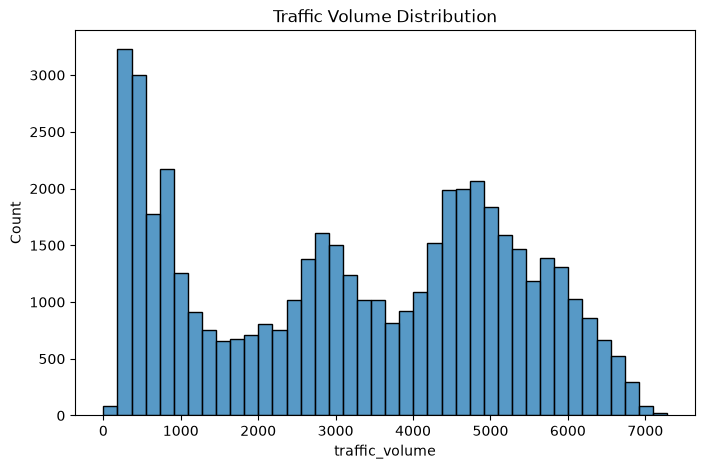

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["traffic_volume"], bins=40)
plt.title("Traffic Volume Distribution")
plt.show()

In [31]:
df["hour"] = df["date_time"].dt.hour

KeyError: 'date_time'

In [32]:
print(df.columns)


Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'Year', 'Month', 'Day', 'Hour',
       'weather_main', 'weather_description', 'traffic_volume'],
      dtype='str')


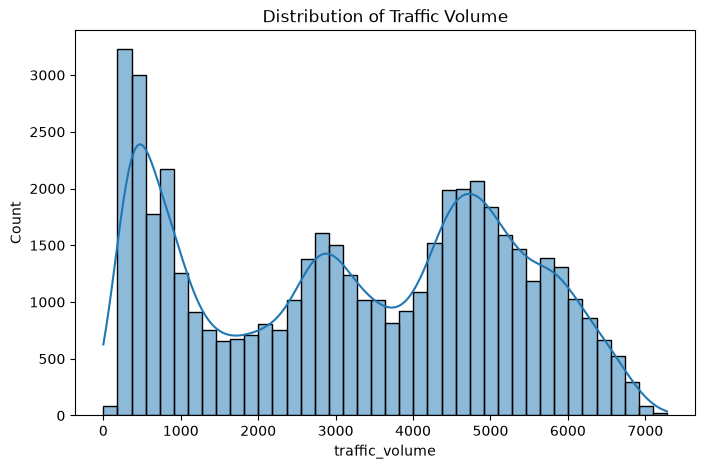

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["traffic_volume"], bins=40, kde=True)

plt.title("Distribution of Traffic Volume")
plt.show()

In [34]:
df.select_dtypes(include="number").columns


Index(['holiday', 'temp', 'snow_1h', 'Year', 'Month', 'Day', 'Hour',
       'weather_main', 'weather_description', 'traffic_volume'],
      dtype='str')

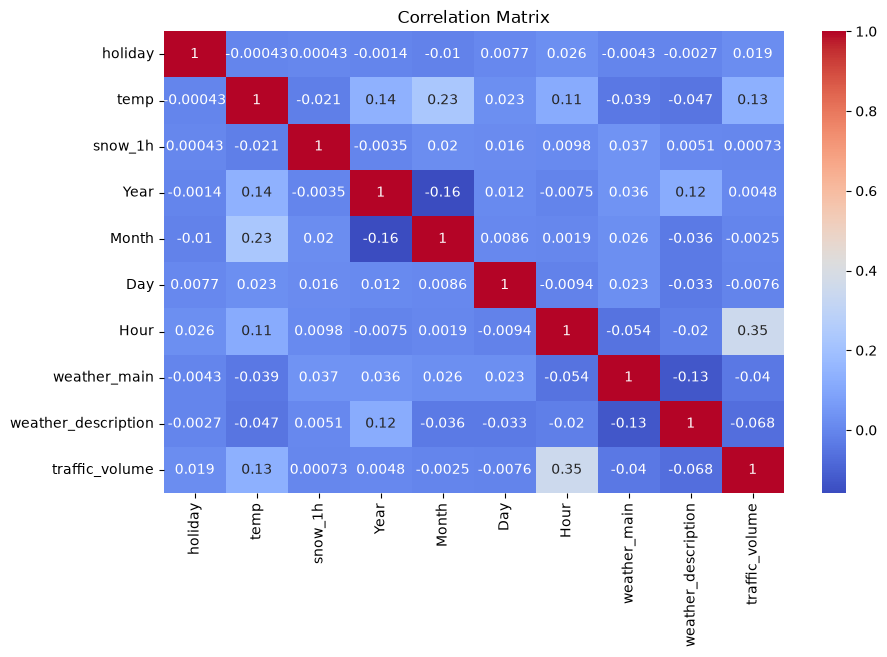

In [35]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

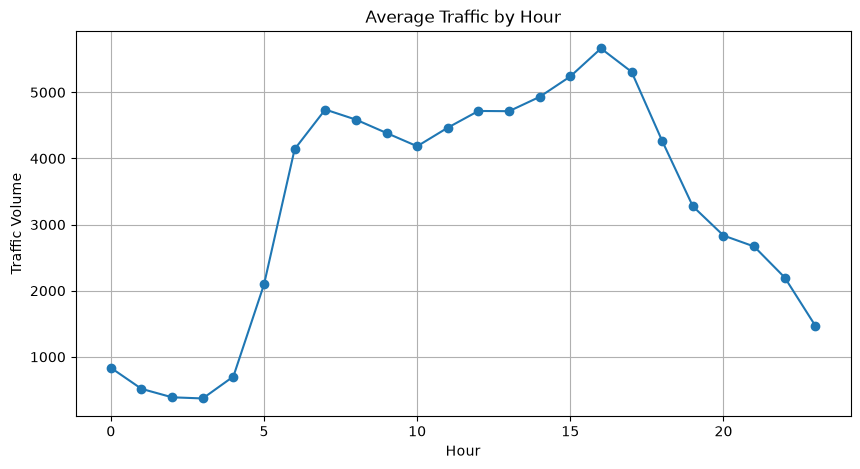

In [36]:
hourly = df.groupby("Hour")["traffic_volume"].mean()

plt.figure(figsize=(10,5))

hourly.plot(marker="o")

plt.grid()

plt.title("Average Traffic by Hour")

plt.xlabel("Hour")

plt.ylabel("Traffic Volume")

plt.show()

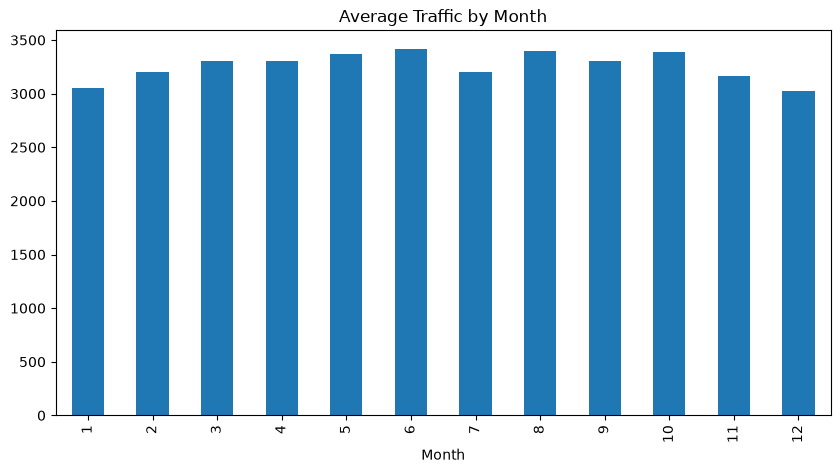

In [37]:
monthly = df.groupby("Month")["traffic_volume"].mean()

plt.figure(figsize=(10,5))

monthly.plot(kind="bar")

plt.title("Average Traffic by Month")

plt.show()

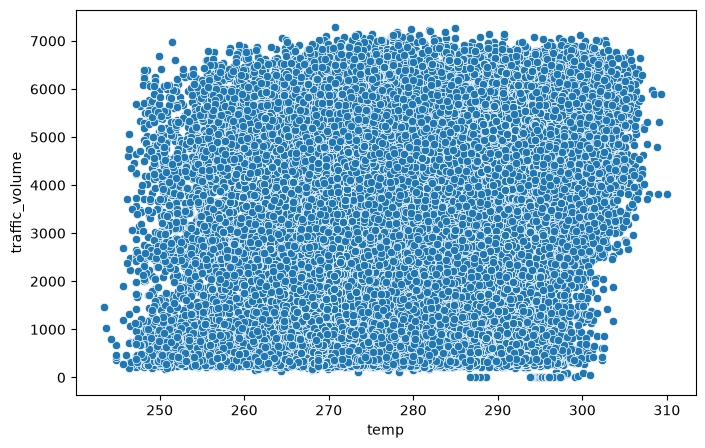

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="temp",
    y="traffic_volume",
    data=df
)

plt.show()

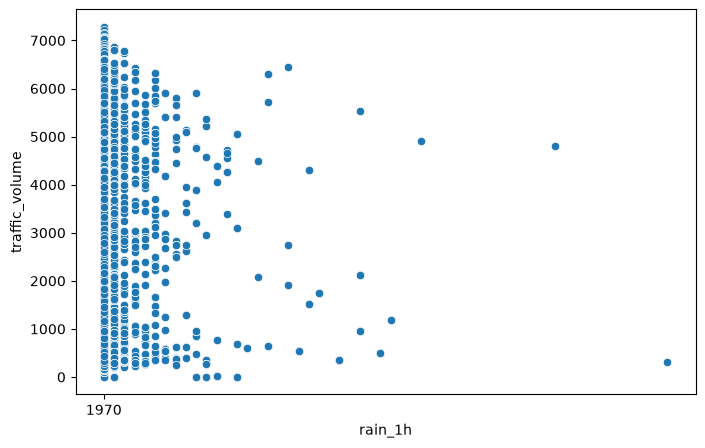

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="rain_1h",
    y="traffic_volume",
    data=df
)

plt.show()

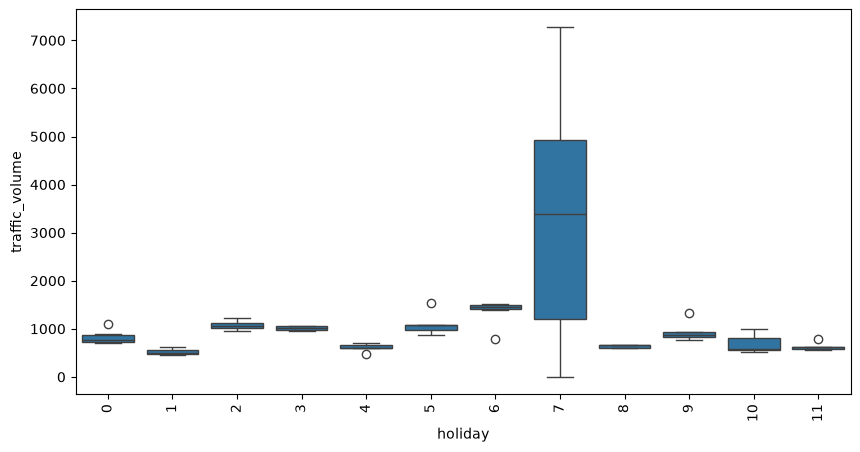

In [40]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="holiday",
    y="traffic_volume",
    data=df
)

plt.xticks(rotation=90)

plt.show()

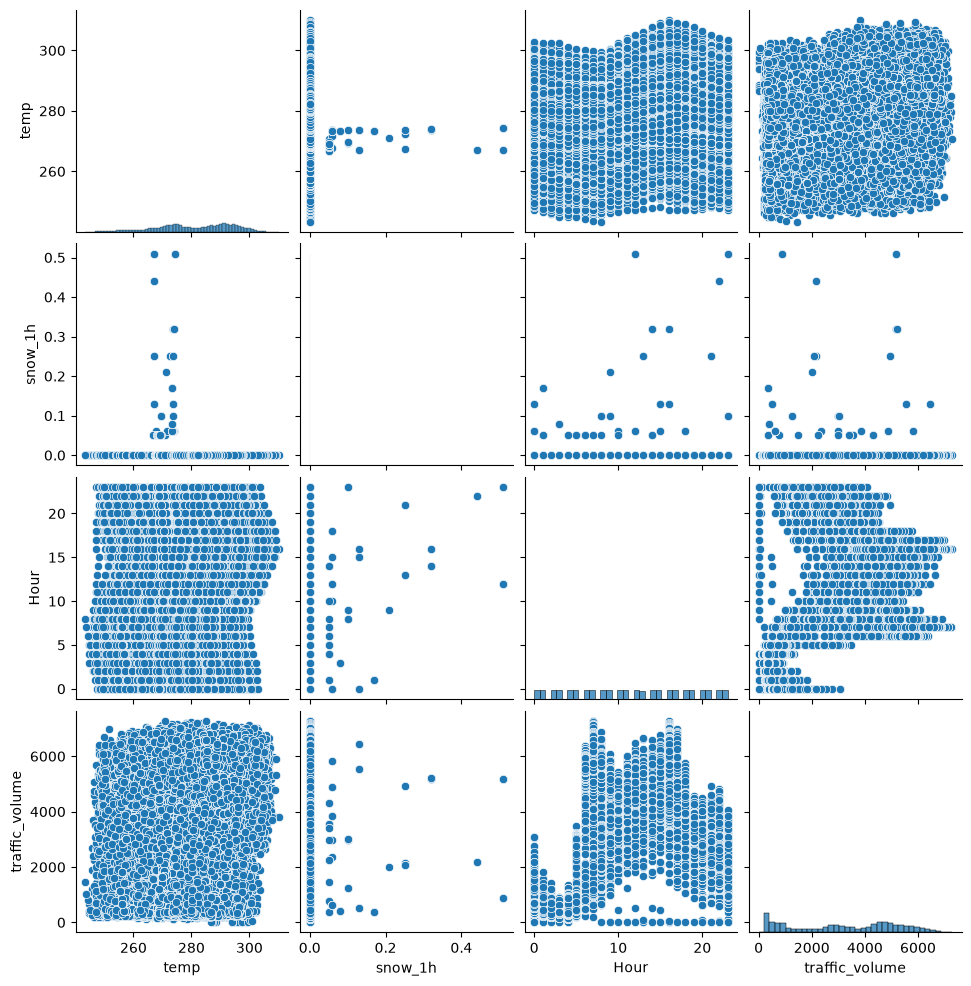

In [41]:
sns.pairplot(
    df[
        [
            "temp",
            "rain_1h",
            "snow_1h",
            "Hour",
            "traffic_volume",
        ]
    ]
)

plt.show()

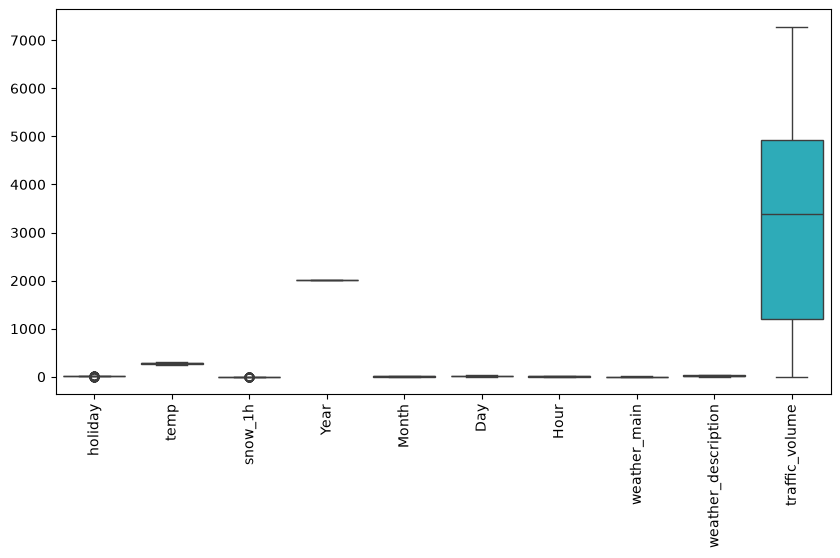

In [42]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

## Observations

- Traffic peaks during office hours.
- Night-time traffic is significantly lower.
- Temperature has a weak correlation with traffic volume.
- Rainfall shows a slight effect on traffic.
- Snowfall is rare in the dataset.
- Holiday traffic appears lower than regular days.